In [30]:
from show_img import show_img
import numpy as np
import cv2

## 1. Перевод в грейтскейл с диапазоном

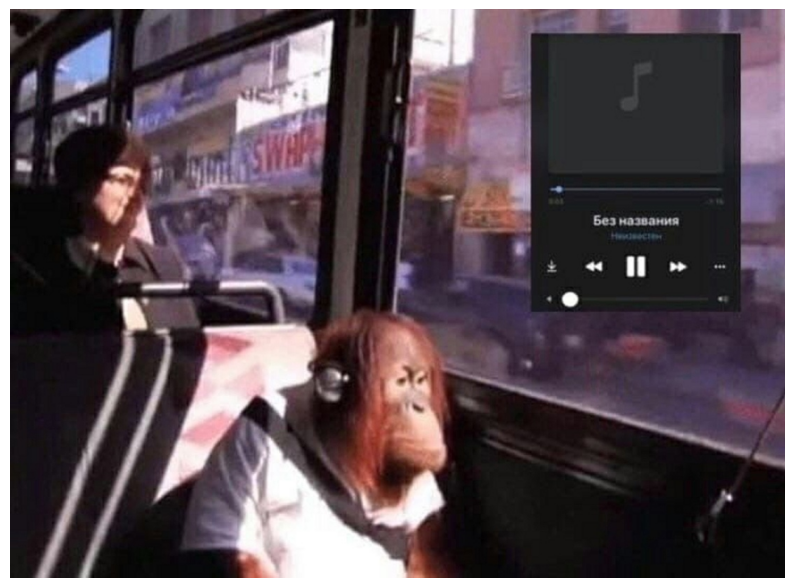

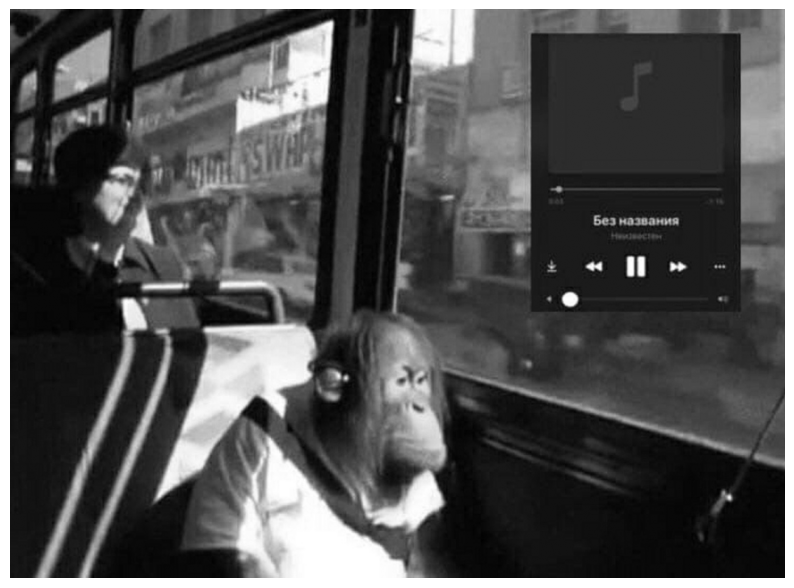

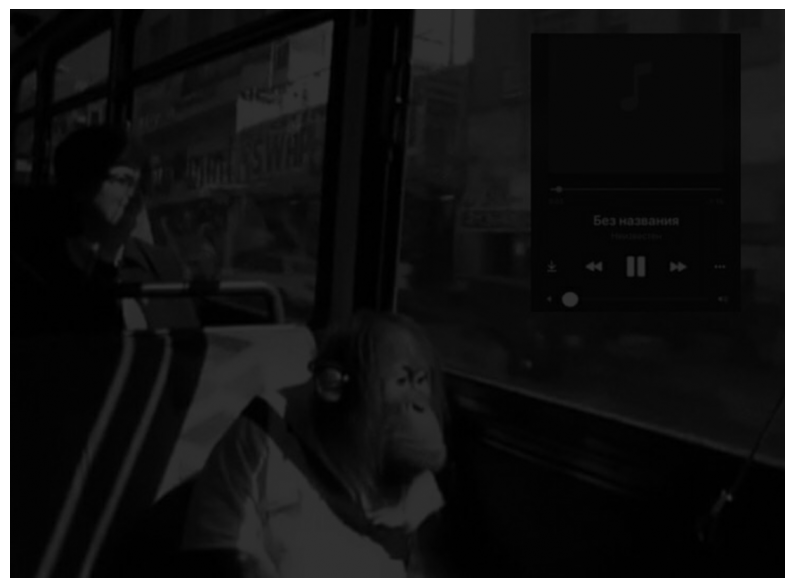

In [31]:
img = cv2.imread("bibizyana.jpg")
show_img(img)
img_grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
show_img(img_grayscale)
range_min, range_max = 0, 50
img_color_min, img_color_max = np.min(img_grayscale), np.max(img_grayscale)

#img_grayscale_range = img_grayscale / 255 * (range_max - range_min) + range_min
img_grayscale_range = ((img_grayscale - img_color_min) / (img_color_max - img_color_min)) \
    * (range_max - range_min) + range_min
img_grayscale_range = img_grayscale_range.astype(np.uint8)
show_img(img_grayscale_range)


## 2. Обратное преобразование

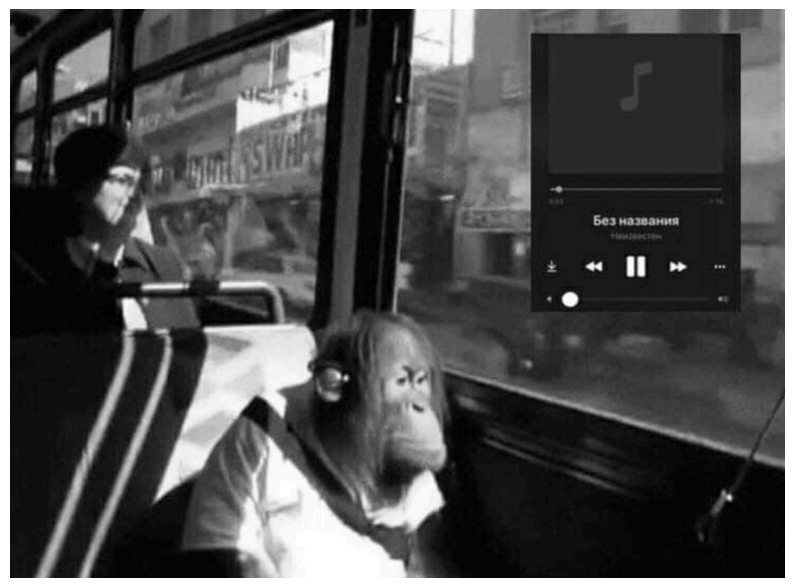

In [32]:
img_grayscale_reverse = (img_grayscale_range - range_min) / (range_max - range_min) \
    * (img_color_max - img_color_min) + img_color_min
img_grayscale_reverse = img_grayscale_reverse.astype(np.uint8)
show_img(img_grayscale_reverse)

## 3. Контрастироование

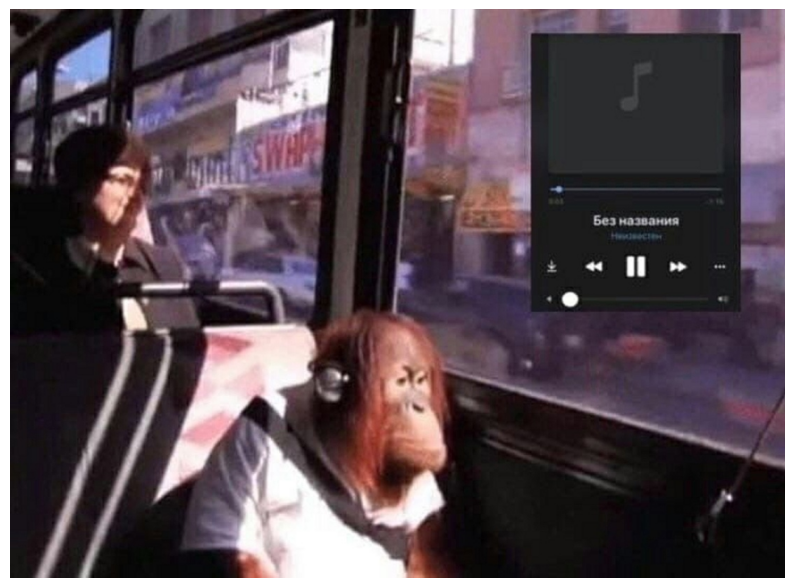

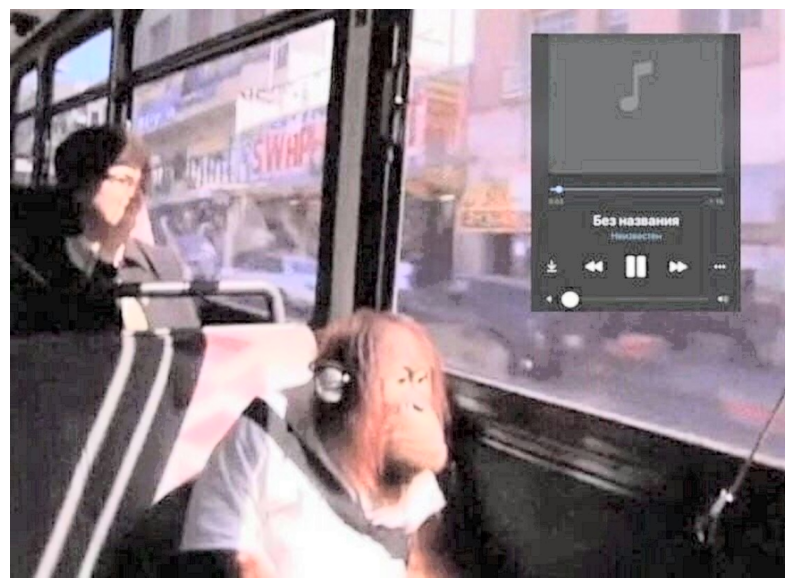

In [33]:
img_yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
img_yuv[:,:,0] = cv2.equalizeHist(img_yuv[:,:,0])
img_eql = cv2.cvtColor(img_yuv, cv2.COLOR_YUV2BGR)

show_img(img)
show_img(img_eql)

## 4. Соляризация

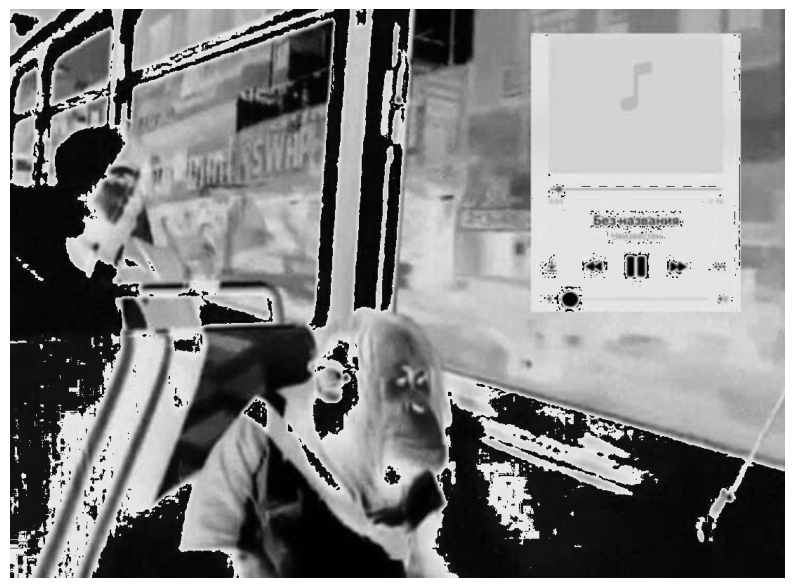

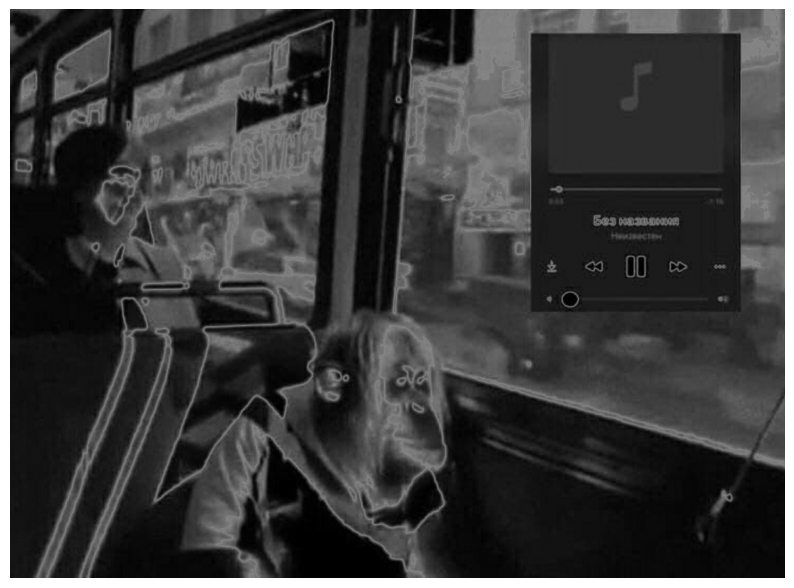

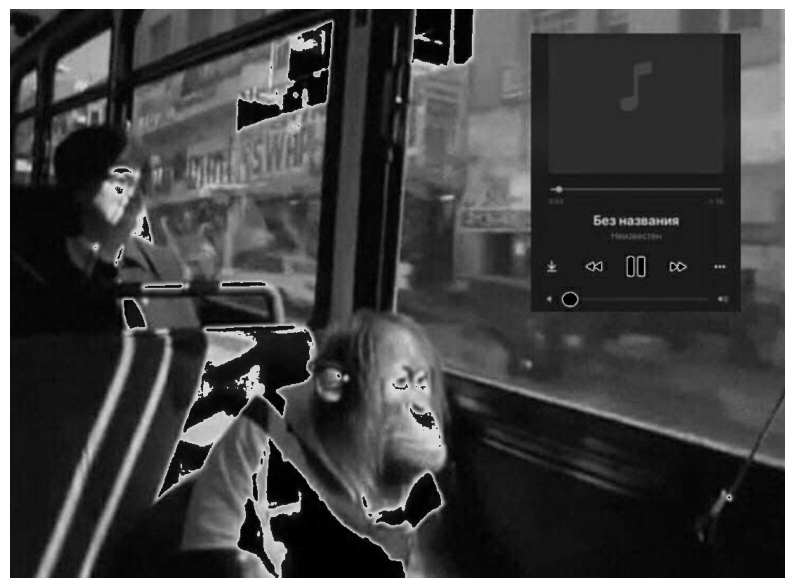

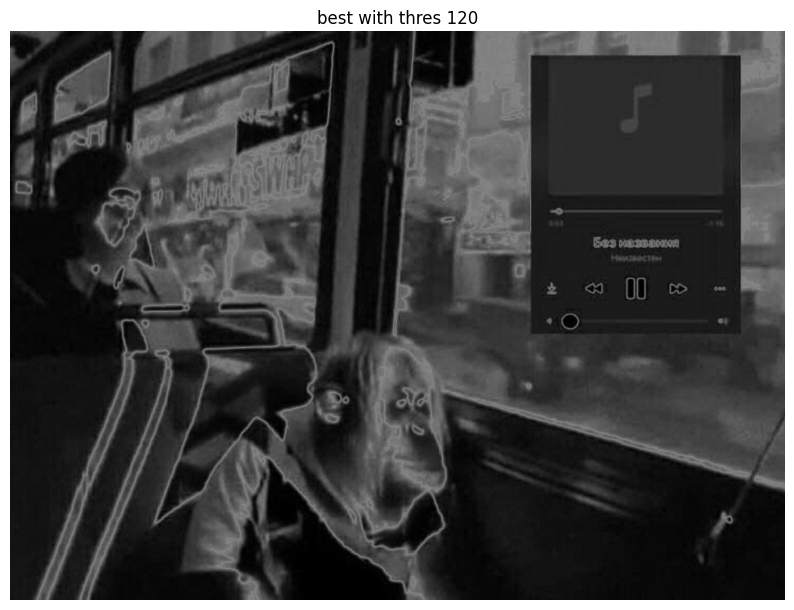

In [34]:
thres_arr = [20, 120, 220]
for thres in thres_arr:
    img_sol = np.where(img_grayscale > thres, 255 - img_grayscale, img_grayscale)
    show_img(img_sol)

thres = 120
img_sol = np.where(img_grayscale > thres, 255 - img_grayscale, img_grayscale)
show_img(img_sol, f"best with thres {thres}")

## 5. Размытие - нечитаемый текст

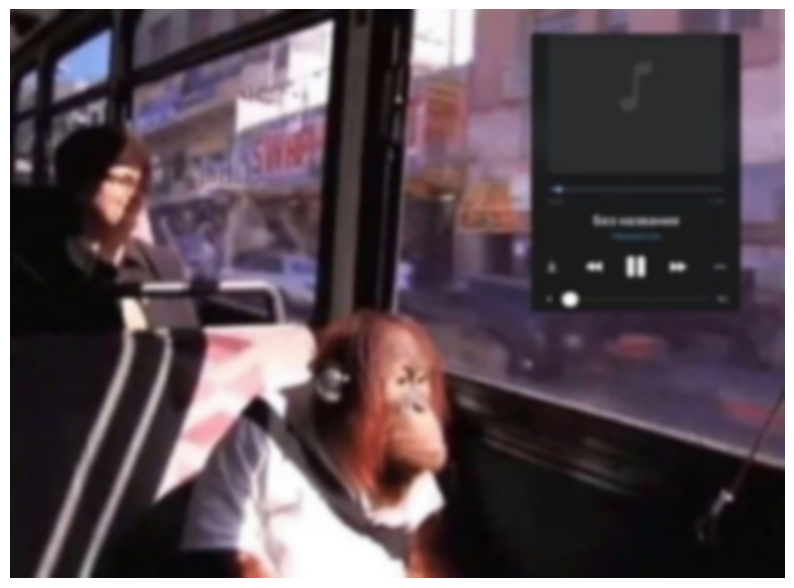

In [35]:
value = 9
img_blur = cv2.GaussianBlur(img, (value * 2 + 1, value * 2 + 1), 0)
show_img(img_blur, size=10)

## 6. Двусторониий фильтр

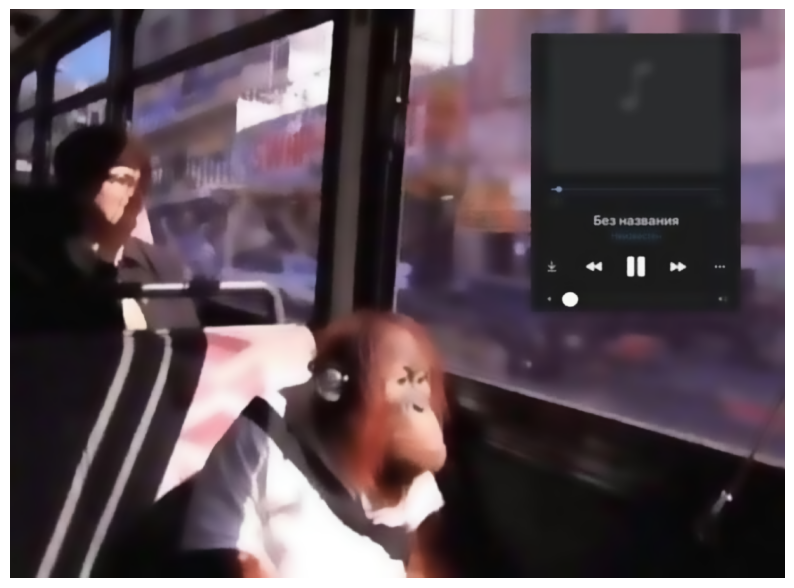

In [36]:
d = 25 # область вокруг пикселя
sigmaColor = 100 # разница цветов пикселей
sigmaSpace = 100 # вес влияния дальних пикселей на центральный 
img_bil = img.copy()
img_bil = cv2.bilateralFilter(img, d=d, sigmaColor=sigmaColor, sigmaSpace=sigmaSpace)
show_img(img_bil)

## 7. Фильтры границ

### Собель

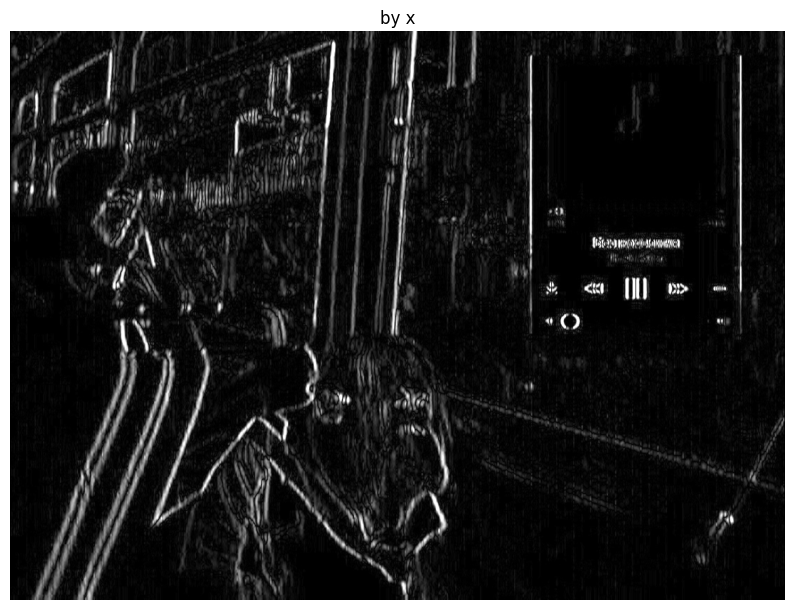

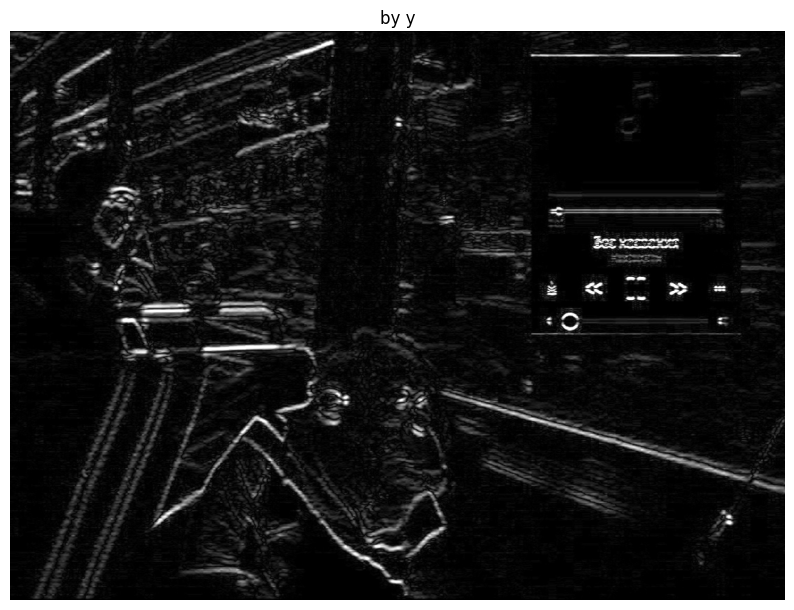

In [37]:
ksize = 1
img_sobel_x_f = cv2.Sobel(img_grayscale, cv2.CV_64F, 1, 0, ksize=ksize*2+1)
img_sobel_y_f = cv2.Sobel(img_grayscale, cv2.CV_64F, 0, 1, ksize=ksize*2+1)
img_sobel_x = cv2.convertScaleAbs(img_sobel_x_f) # перевод обратно в uint8
img_sobel_y = cv2.convertScaleAbs(img_sobel_y_f)

show_img(img_sobel_x, "by x")
show_img(img_sobel_y, "by y")

### Лапласа

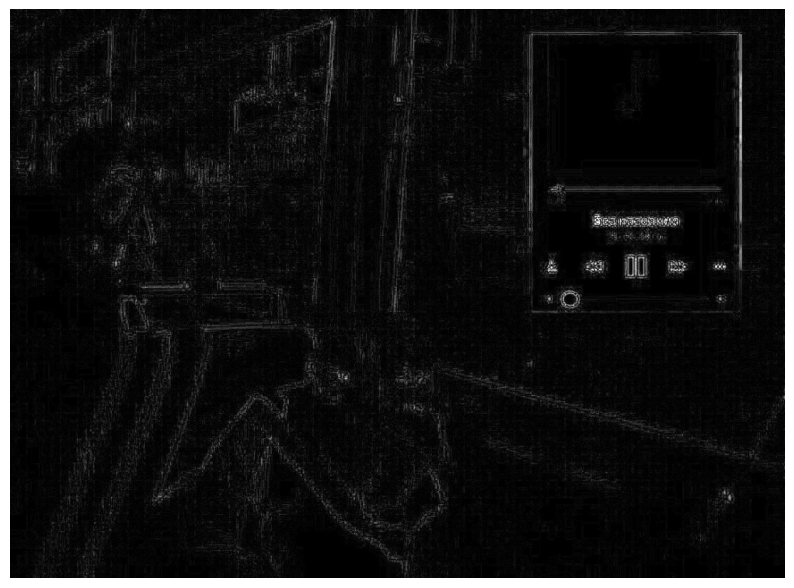

In [38]:
img_lap_f = cv2.Laplacian(img_grayscale, cv2.CV_64F, ksize=3)
img_lap = cv2.convertScaleAbs(img_lap_f)
show_img(img_lap)

### Канни

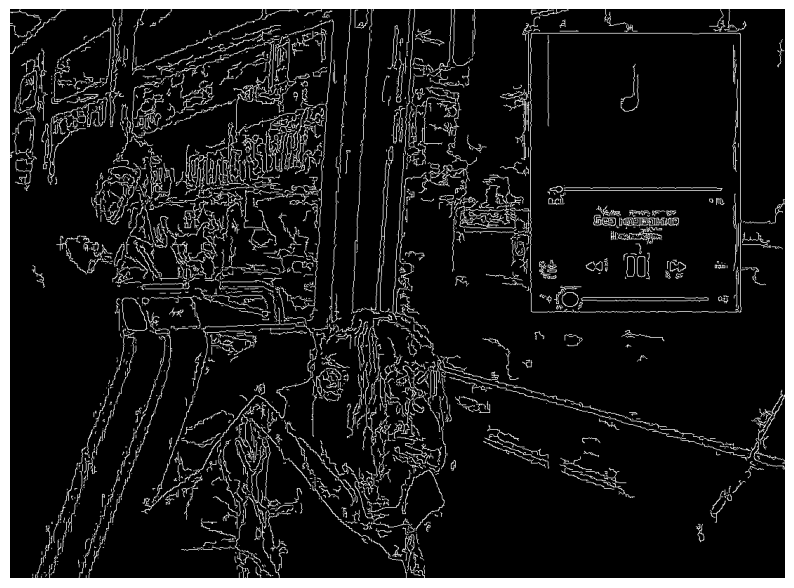

In [39]:
img_canny = cv2.Canny(img, 20, 80)
show_img(img_canny)